Completed in 5.67 s.                                               


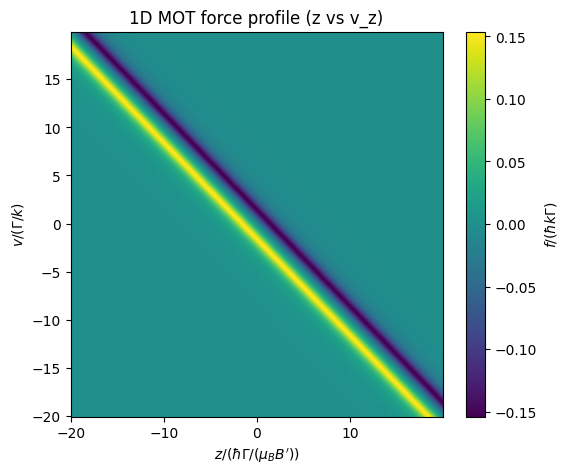

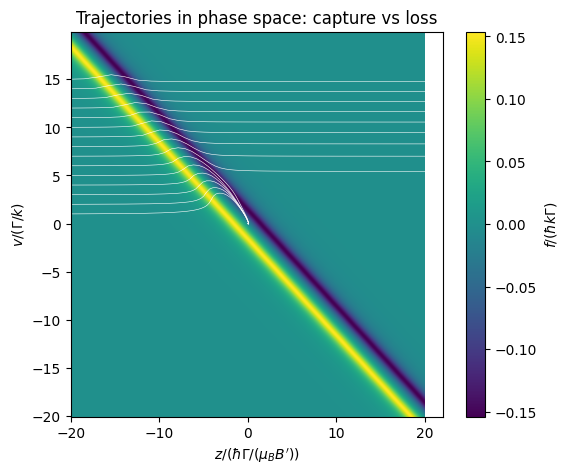

Capture velocity v_c (in units Γ/k) =  6.20770263671875


In [4]:
#example from pylcp
# Imports and constants
import numpy as np
import pylcp
import matplotlib.pyplot as plt
from scipy import constants as cts
from scipy.optimize import bisect

from pylcp import atom, laserBeams, quadrupoleMagneticField, heuristiceq


# Unit & atomic parameters  
# (These follow the doc example's „bar‐units” choice.)
gamma = 1.0            # normalized (Γ=1) in this unit system  
alpha = 1.0            # gradient parameter in normalized units  
s0 = 1.0               # saturation parameter  
delta = -1.5           # detuning (in units of Γ)  
# Mass in normalized units — compute from real values if desired  
m_real = 86.909 * cts.value('atomic mass constant')  
# The doc computes a normalized mass; you can replicate that if you like  
# Here we simply set:
mbar = 0.03454474231473474  

# Define beam + magnetic field  
beams = laserBeams([
    {'kvec': np.array([0., 0., 1.]), 'pol': np.array([0., 0., 1.]), 's': s0, 'delta': delta},
    {'kvec': np.array([0., 0., -1.]), 'pol': np.array([1., 0., 0.]), 's': s0, 'delta': delta}
], beam_type=pylcp.infinitePlaneWaveBeam)

magField = quadrupoleMagneticField(alpha)

# Define the equation of motion (heuristic version)  
eqn = heuristiceq(beams, magField, gamma=gamma, mass=mbar)

# 2D phase space grid for z and v_z  
dz = 0.1
dv = 0.1
z = np.arange(-20, 20 + dz, dz)
v = np.arange(-20, 20 + dv, dv)

Z, V = np.meshgrid(z, v)
Rfull = np.array([np.zeros(Z.shape), np.zeros(Z.shape), Z])
Vfull = np.array([np.zeros(Z.shape), np.zeros(Z.shape), V])

# Generate the force profile (F_z component)  
eqn.generate_force_profile(Rfull, Vfull, name='Fz', progress_bar=True)

# Plot the force map  
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(eqn.profile['Fz'].F[2],
               origin='lower',
               extent=(np.min(z)-dz/2, np.max(z)-dz/2,
                       np.min(v)-dv/2, np.max(v)-dv/2),
               aspect='auto')

cb = fig.colorbar(im)
cb.set_label(r'$f/(\hbar k \Gamma)$')
ax.set_xlabel(r'$z/(\hbar \Gamma/(\mu_B B^\prime))$')
ax.set_ylabel(r'$v/(\Gamma/k)$')
ax.set_title('1D MOT force profile (z vs v_z)')
plt.show()

# Trajectory evolution: capture vs loss  
v0s = np.arange(1, 15.5, 1.0)

def captured_condition(t, y, threshold=1e-5):
    # y vector includes position, velocity
    # Here we assume y[-4] is z-position, y[-1] is v_z (per doc)
    if (y[-4] < threshold) and (y[-1] < 1e-3):
        return -1.0
    else:
        return 1.0

def lost_condition(t, y, threshold=20.):
    if y[-1] > threshold:
        return -1.0
    else:
        return 1.0

captured_condition.terminal = True
lost_condition.terminal = True

sols = []
z0 = z[0]
for v0 in v0s:
    eqn.set_initial_position_and_velocity(np.array([0.,0.,z0]),
                                          np.array([0.,0.,v0]))
    eqn.evolve_motion([0., 100.], events=[captured_condition, lost_condition], max_step=0.1)
    sols.append(eqn.sol)

# Plot trajectories over force map  
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(eqn.profile['Fz'].F[2],
               origin='lower',
               extent=(np.min(z)-dz/2, np.max(z)-dz/2,
                       np.min(v)-dv/2, np.max(v)-dv/2),
               aspect='auto')
cb = fig.colorbar(im)
cb.set_label(r'$f/(\hbar k \Gamma)$')
ax.set_xlabel(r'$z/(\hbar \Gamma/(\mu_B B^\prime))$')
ax.set_ylabel(r'$v/(\Gamma/k)$')
for sol in sols:
    ax.plot(sol.r[2], sol.v[2], 'w-', linewidth=0.4)
ax.set_title('Trajectories in phase space: capture vs loss')
plt.show()

# Find capture velocity via root‐finding  
def is_captured(v0, z0, eqn, cap_cond, loss_cond, tmax=1000., max_step=0.1):
    eqn.set_initial_position_and_velocity(np.array([0.,0.,z0]),
                                          np.array([0.,0.,v0]))
    eqn.evolve_motion([0., tmax], events=[cap_cond, loss_cond], max_step=max_step)
    if len(eqn.sol.t_events[0]) == 1:
        return 1.0
    else:
        return -1.0

vc_root = bisect(is_captured, 1.0, 15.0,
                 args=(z0, eqn, captured_condition, lost_condition),
                 xtol=1e-4, rtol=1e-4)
print("Capture velocity v_c (in units Γ/k) = ", vc_root)
